# Searching for a Needle in a "Signal Haystack" with recording

### use https://onlinetonegenerator.com/

In [1]:
from pathlib import Path
import sys

COURSEUTILS_DIR = Path.home() / "Documents/GitHub/Signals_and_Systems/courseutils"
sys.path.insert(0, str(COURSEUTILS_DIR))

In [2]:
import basic_material as bm
if hasattr(bm, "setup_environment"):
    bm.setup_environment()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Audio/recording dependencies used by later cells
import os
import time
import pyaudio
import librosa, librosa.display
from scipy.io.wavfile import write
import IPython.display as ipd

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [4]:
# store data
def store_data(signal,stack):
    # sum will treat Boolean True as a 1, False as a 0
    n = sum(os.path.isfile("data/"+name) for name in os.listdir('data/'))
    file_name = "data/Store_%s" % n 
    print("\nStoring recorded data in",file_name)

    np.savetxt(file_name+"_signal.csv", signal, delimiter=",")
    np.savetxt(file_name+"_stack.csv", stack, delimiter=",")

    signal_read = np.loadtxt(file_name+"_signal.csv",delimiter=',',skiprows=0)  
    stack_read = np.loadtxt(file_name+"_stack.csv",delimiter=',',skiprows=0)  

    print(f"Signal reload errors of {np.max(np.abs(signal_read - signal)):.6e}")
    print(f"Stack reload errors of {np.max(np.abs(stack_read - stack)):.6e}\n")
    
    return file_name

## Pattern Matching

* Thus we have to do pattern matching - we basically create a replica signal as 
above, and then choose a range of $0\leq\phi\leq 2\pi$ to see if any match better than others

* Matching deptermined by computing the *correlation*
$$ C[j] =\sum_i y_{meas}[i] y_{replica}[i,j]$$
where $i$ is the index over mesurements taken and $j$ determines what value of $\phi$ is being used

* Here we explicitly sweep the phase in the replica signal, so the heatmap x-axis is the actual tested phase $\phi$.

* We don't know the right amplitude to use either, but that is a scaling error in all $C[j]$ values - so can just look for the largest value across all computed.

In [5]:
# Implement the correlation process between the measured signal and phase-shifted replicas
def phase_correlate(y_meas, omega_test, tvals, PHI):
    y0 = np.asarray(y_meas) - np.mean(y_meas)
    C = np.zeros(len(PHI))

    for ii, phi in enumerate(PHI):
        y_ref = np.sin(omega_test*tvals + phi)
        y_ref = y_ref - np.mean(y_ref)

        denom = np.linalg.norm(y0) * np.linalg.norm(y_ref)
        C[ii] = np.dot(y0, y_ref) / denom

    return C


In [6]:
FORMAT = pyaudio.paInt16
CHANNELS = 1
sr = 44100
dt = 1/sr
chunk_size = 512
WAVE_OUTPUT_FILENAME = "data/TF_recordedFile.wav"
audio = pyaudio.PyAudio()

In [7]:
p = pyaudio.PyAudio()
device_keep_list = []

print("----------------------record device list---------------------")
info = p.get_host_api_info_by_index(0)
numdevices = info.get('deviceCount')

for i in range(numdevices):
    dev = p.get_device_info_by_host_api_device_index(0, i)

    if dev.get('maxInputChannels') > 0:
        name = dev.get('name')
        print(f"Input Device id {i} - {name}")

        if name.startswith('MacBook'):
            device_keep_list.append((i, name))

print("-------------------------------------------------------------")

device_keep_id, device_keep_name = device_keep_list[0]

print("Selected input device:", device_keep_name)

----------------------record device list---------------------
Input Device id 2 - JHow72 Microphone
Input Device id 3 - Insta360 Link
Input Device id 4 - MacBook Pro Microphone
Input Device id 6 - Camo Microphone
Input Device id 7 - Microsoft Teams Audio
Input Device id 8 - ZoomAudioDevice
-------------------------------------------------------------
Selected input device: MacBook Pro Microphone


In [8]:
tf = 12 # amount of data to collect
hop_length = 256  # step size between successive frames in samples
t_start = 1 # start time for processing

stream = p.open(
    format=pyaudio.paFloat32,
    channels=1,
    rate=sr,
    input=True,
    input_device_index=device_keep_id,
    frames_per_buffer=chunk_size,
)
alldata =[]
frames = []

start = time.time()
t_now = start
while (time.time() < start + tf):
    data = stream.read(chunk_size,exception_on_overflow = False)
    DATA = np.frombuffer(data, dtype=np.float32)
    alldata.append(DATA)
    # Use a mel-bank size that matches the available FFT bins in the chosen fmax range.
    melspec = librosa.feature.melspectrogram(
        y=DATA,
        sr=sr,
        n_fft=chunk_size,
        hop_length=max(1, chunk_size // 4),
        n_mels=24,
        fmax=4096/2,
    )
    norm_melspec = librosa.core.power_to_db(melspec, ref = np.max)
    frames.append(norm_melspec)
    if time.time() - t_now > 0.5:
        print(f"{time.time() - start:.1f} ",  end = '')
        t_now = time.time()

signal = np.hstack(alldata)
stack = np.hstack(frames)

stored_file_names = store_data(signal,stack)

y = signal
N = len(y) # number of pts collected
t = np.arange(N)/sr # time array
tf = np.max(t) # amount of data actually collected
amp = np.max(np.abs(y)) # ampltiude of signal

N_start = np.argwhere(t >= t_start)[0][0] # where to start processing
sl = slice(N_start,-1)

2.0 2.5 3.1 3.6 4.1 4.6 5.1 5.6 6.1 6.6 7.1 7.6 8.1 8.6 9.1 9.7 10.2 10.7 11.2 11.7 
Storing recorded data in data/Store_267
Signal reload errors of 0.000000e+00
Stack reload errors of 0.000000e+00



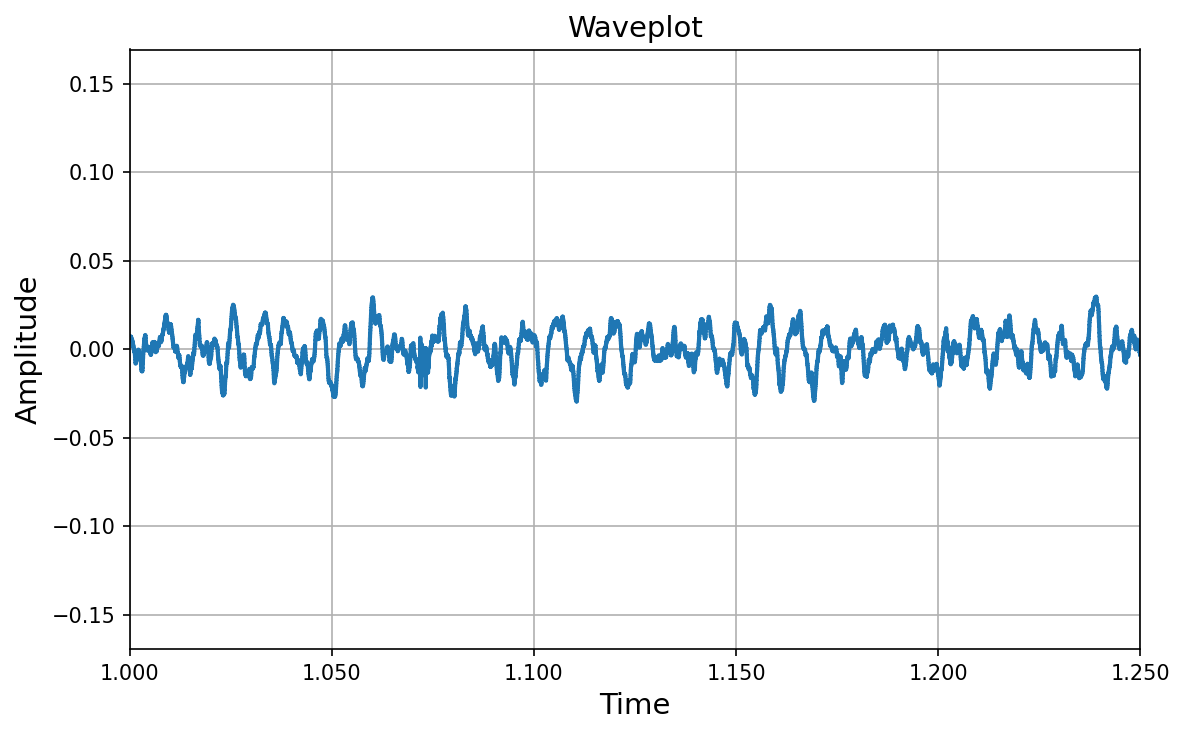

Signal saved as 'data/Store_267.wav'


In [9]:
plt.figure(figsize=(8, 5))
h = librosa.display.waveshow(signal, sr=sr)
plt.title('Waveplot', fontdict=dict(size=14))
plt.xlabel('Time', fontdict=dict(size=14))
plt.ylabel('Amplitude', fontdict=dict(size=14))
plt.xlim(t_start,t_start+0.25)
#plt.savefig('./figs/mic_0.png', bbox_inches='tight', dpi=300)
plt.show()

# Normalize the signal to the range of int16
Signal = np.int16(signal / np.max(np.abs(signal)) * 32767)

# Save the signal as a WAV file
write(stored_file_names+'.wav', sr, Signal)

print(f"Signal saved as '{stored_file_names+'.wav'}'")

In [10]:
if 1:
    omega_lower_bound = 100*2*np.pi
    omega_upper_bound = 400*2*np.pi
    omega_guess = 200*2*np.pi
else:
    #https://onlinetonegenerator.com/multiple-tone-generator.html?f[]=440&f[]=600&f[]=800&w[]=si&w[]=si&w[]=si&v[]=15&v[]=36&v[]=18
    omega_lower_bound = 400*2*np.pi
    omega_upper_bound = 500*2*np.pi
    omega_guess = 400*2*np.pi

# Sweep actual phase values, not sample-shift indices
Nphi = 100
PHI = np.linspace(0, 2*np.pi, Nphi, endpoint=False)


## Now back to analyzing the meaured data

In [11]:
# Set up a range of possible Omega values
Nw = 2 * Nphi
omega_range = np.linspace(omega_lower_bound, omega_upper_bound, Nw)
N_omega = (np.abs(omega_range - omega_guess)).argmin()

CC = np.zeros((len(omega_range), len(PHI)))
for ii, om in enumerate(omega_range):
    CC[ii, :] = phase_correlate(y[sl], om, t[sl], PHI)

CC /= np.max(CC)

# Look for best correlation across all frequency and phase sweeps
ind, N_phi_pred = np.unravel_index(np.argmax(CC), CC.shape)
omega_pred = omega_range[ind]
f_pred = omega_pred / (2*np.pi)
phi_pred = PHI[N_phi_pred]

print(f'Pred Freq {f_pred:.1f} Hz')
print(f'Pred Phi {phi_pred:.2f} rad')


Pred Freq 136.2 Hz
Pred Phi 3.02 rad


In [12]:
def set_sparse_yticks(omega_range, ind, Nw, step=50, min_sep=20, maxticks=8):
    """
    Set y-ticks for imshow with:
    - symmetric ticks around ind using ±step*k
    - inclusion of endpoints (0, Nw-1)
    - removal of ticks that are too close
    """

    # Generate symmetric indices
    k_min = -(ind // step)
    k_max = (Nw - 1 - ind) // step
    idxs = [ind + k * step for k in range(k_min, k_max + 1)]

    # Include endpoints and center
    idxs = sorted(set([0, ind, Nw - 1] + idxs))

    # Filter out ticks that are too close
    filtered = []
    for i in idxs:
        if not filtered or abs(i - filtered[-1]) >= min_sep:
            filtered.append(i)

    if len(filtered) > maxticks:
        stride = int(np.ceil(len(filtered) / maxticks))
        filtered = filtered[::stride]
        if ind not in filtered:
            # Find closest index in filtered to ind and replace it with ind
            closest_idx = min(range(len(filtered)), key=lambda i: abs(filtered[i] - ind))
            filtered[closest_idx] = ind
        filtered = sorted(filtered)

    # Create labels
    labels = [f"{omega_range[i]:.1f}" for i in filtered]

    # Apply
    plt.yticks(filtered, labels)


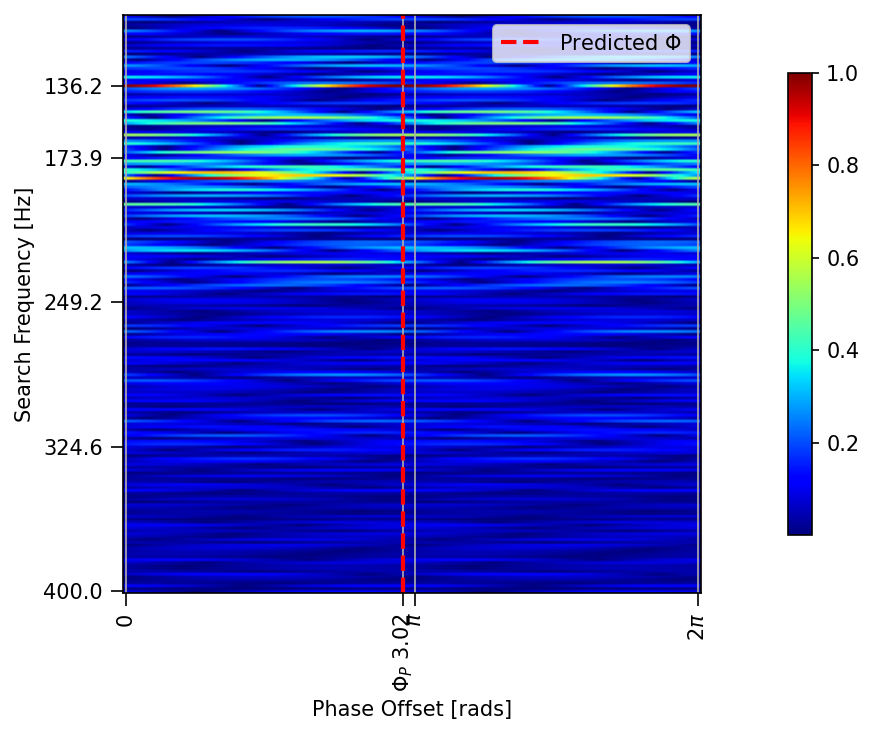

In [13]:
fig = plt.figure(figsize=(12, 5))
im = plt.imshow(np.abs(CC), cmap='jet', aspect=Nphi/Nw)
set_sparse_yticks(
    omega_range / (2 * np.pi),
    ind,
    Nw,
    step=max(1, Nw // 8),
    min_sep=max(1, Nw // 20),
    maxticks=6,
 )

plt.axvline(x=N_phi_pred, color='red', ls='--', label='Predicted $\Phi$')

xticks = [0, Nphi//2, N_phi_pred, Nphi-1]
xticklabels = [
    '0',
    '$\pi$',
    f'$\Phi_P$ {phi_pred:.2f}',
    '$2\pi$',
]
plt.xticks(xticks, xticklabels, rotation=90)

plt.ylabel('Search Frequency [Hz]')
plt.xlabel('Phase Offset [rads]')
plt.colorbar(shrink=0.8)
plt.tick_params(axis='both', which='both', direction='out', length=6, top=False, right=False)
plt.grid(axis='x', linestyle='-')
plt.grid(axis='y', visible=False)
plt.legend()
plt.show()
#fig.savefig('./figs/Correlation3.png', dpi=300)


## Alternate Approach

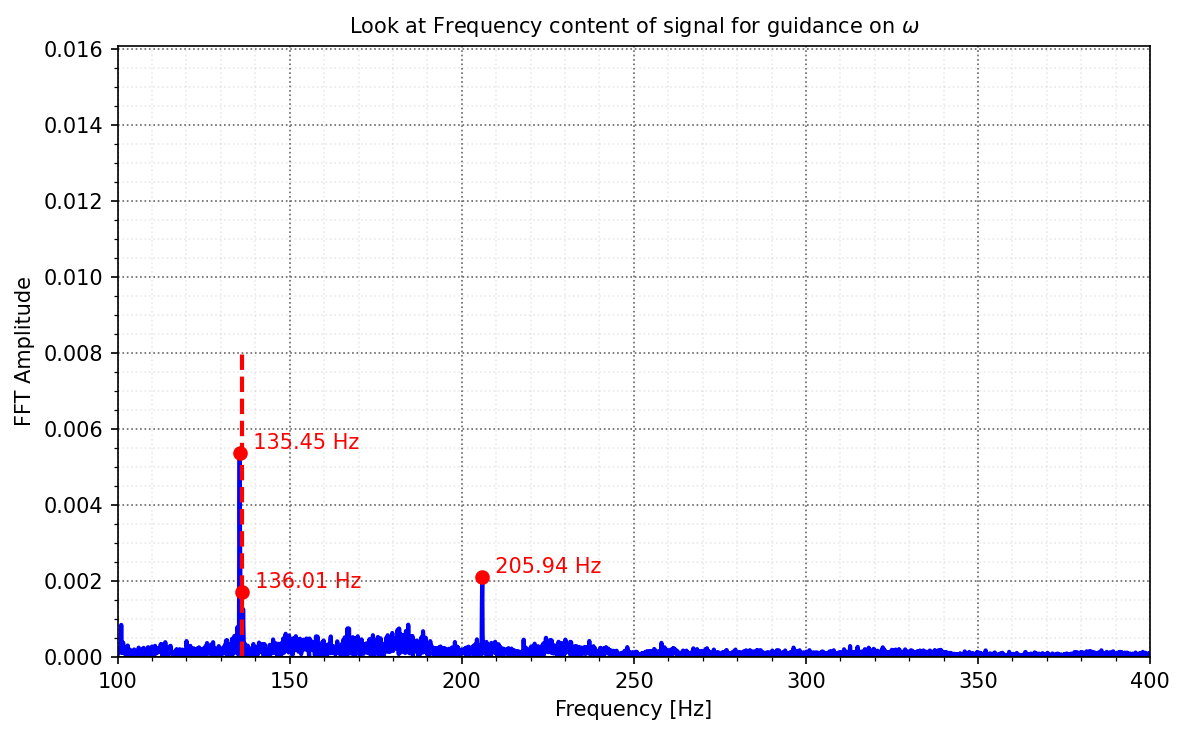

Top 3 FFT peaks:
f = 135.454 Hz, omega = 851.081 rad/s, amp = 0.00536
f = 136.005 Hz, omega = 854.546 rad/s, amp = 0.0017
f = 205.938 Hz, omega = 1293.948 rad/s, amp = 0.00212


In [14]:
# Alternate way to estimate Omega given the measured data - look for the peak in the FFT plot
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

yf = fft(y[sl])
Nfft = len(yf)

freq_hz = fftfreq(Nfft, dt)[1:Nfft//2]
ff = 2*np.pi*freq_hz
amp = 2.0/Nfft * np.abs(yf[1:Nfft//2])

# only search in the plotted frequency window
f_lower = omega_lower_bound / (2*np.pi)
f_upper = omega_upper_bound / (2*np.pi)
search_mask = (freq_hz >= f_lower) & (freq_hz <= f_upper)

peaks, _ = find_peaks(amp[search_mask])
search_freqs = freq_hz[search_mask]
search_amp = amp[search_mask]

# top 3 peaks by amplitude
top_local = peaks[np.argsort(search_amp[peaks])[-3:]]
top_local = top_local[np.argsort(search_freqs[top_local])]

peak_freqs = search_freqs[top_local]
peak_amps = search_amp[top_local]

ind_f = (np.abs(freq_hz - f_pred)).argmin()
aamp = 1.5*np.max(amp[max(0, ind_f-100):min(len(amp), ind_f+100)])

fig = plt.figure(figsize=(8, 5))
plt.plot(freq_hz, amp, 'b-')
plt.plot([f_pred, f_pred], [0, aamp], 'r--')

# show top 3 peak frequencies in red
plt.plot(peak_freqs, peak_amps, 'ro')
for fp, ap in zip(peak_freqs, peak_amps):
    plt.text(fp, ap, f'  {fp:.2f} Hz', color='red',
             ha='left', va='bottom', rotation=0)

plt.ylabel('FFT Amplitude')
plt.xlabel('Frequency [Hz]')
plt.xlim([f_lower, f_upper])
plt.ylim([0, aamp*2])
plt.title("Look at Frequency content of signal for guidance on $\\omega$")
bm.nicegrid()
plt.show()

print("Top 3 FFT peaks:")
for fp, ap in zip(peak_freqs, peak_amps):
    print(f"f = {fp:.3f} Hz, omega = {2*np.pi*fp:.3f} rad/s, amp = {ap:.3g}")

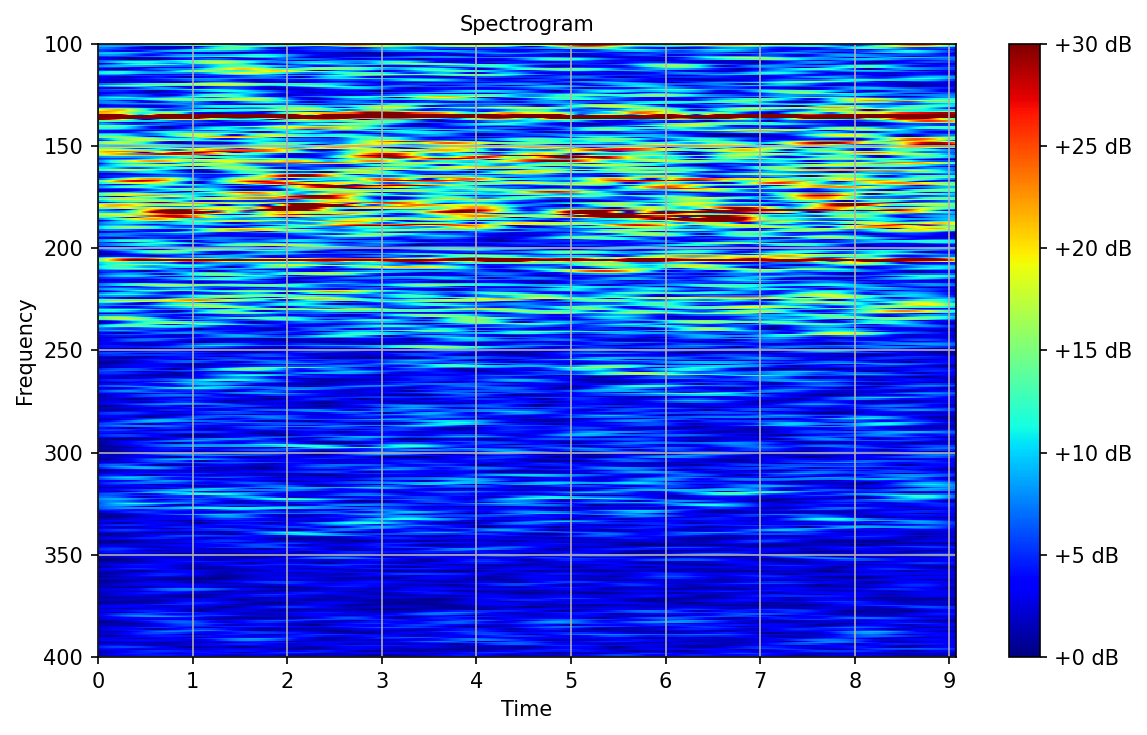

In [15]:
# Compute the spectrogram using STFT
S = np.abs(librosa.stft(y[sl],n_fft=2**16,hop_length=hop_length))

# Display the spectrogram
plt.figure(figsize=(8, 5))
librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='fft', hop_length=hop_length, cmap='jet')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylim([omega_upper_bound/2/np.pi, omega_lower_bound/2/np.pi])
plt.ylabel('Frequency')
plt.clim(0, 30)
plt.show()

In [16]:
ipd.Audio(np.int16(y[sl] / np.max(np.abs(y[sl])) * 32767), rate=sr)

In [17]:
import numpy as np 
hop_length = 256
sr = 44100

# 528
stored_file_names = "data/Store_548"

data_bells_stack = np.loadtxt(stored_file_names+'_stack.csv',delimiter=',',skiprows=0)  
data_bells_signal = np.loadtxt(stored_file_names+'_signal.csv',delimiter=',',skiprows=0)  

N = len(data_bells_signal) # number of pts collected
t = np.arange(N)/sr # time array
tf = np.max(t) # amount of data actually collected

N_start = np.argwhere(t >= 1)[0][0] # where to start processing
sl = slice(N_start,-1)

# Compute the spectrogram using STFT
Sbells = np.abs(librosa.stft(data_bells_signal[sl],n_fft=2**16,hop_length=hop_length))

write(stored_file_names+'.wav', sr, data_bells_signal)
ipd.Audio(np.int16(data_bells_signal / np.max(np.abs(data_bells_signal)) * 32767), rate=sr)

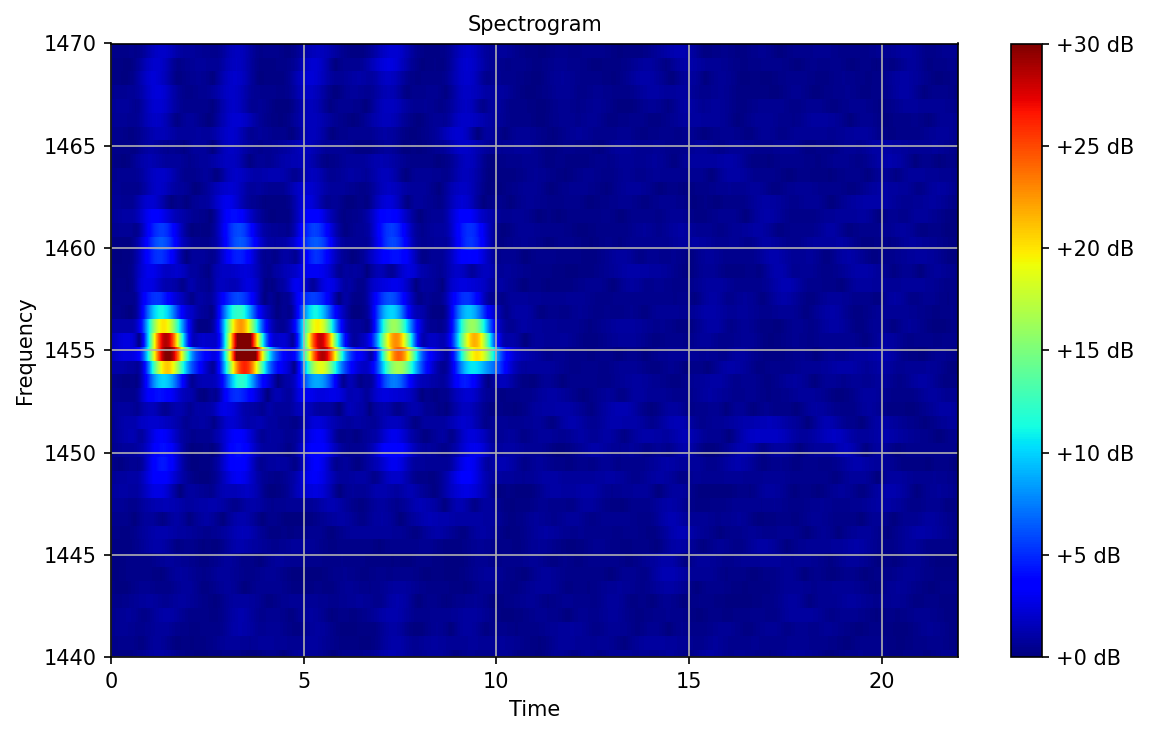

In [18]:
# Display the spectrogram
plt.figure(figsize=(8, 5))
librosa.display.specshow(Sbells, sr=sr, x_axis='time', y_axis='fft', hop_length=hop_length, cmap='jet')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylim([1440, 1470])
plt.ylabel('Frequency')
plt.clim(0, 30)
plt.show()